Note on fine-tuning:
In deep learning, fine-tuning usually refers to starting from a pretrained model (like one trained on ImageNet) and adapting it to a new task by continuing training, often with lower learning rates or by freezing some layers. In this exercise, we are explicitly told not to use fine-tuning or pretrained models. However, adjusting hyperparameters like learning rate, batch size, dropout, and using data augmentation is still part of training from scratch — and is allowed. I have built the VGG11-based model manually and trained it from scratch without loading any pretrained weights.

training_images shape: (1500, 3, 96, 96)
training_labels shape: (1500,)
                                              images  labels
0  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       2
1  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       1
2  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       0
3  [[[218, 216, 216, 216, 218, 218, 216, 217, 220...       0
4  [[[181, 178, 177, 181, 184, 184, 185, 187, 190...       1


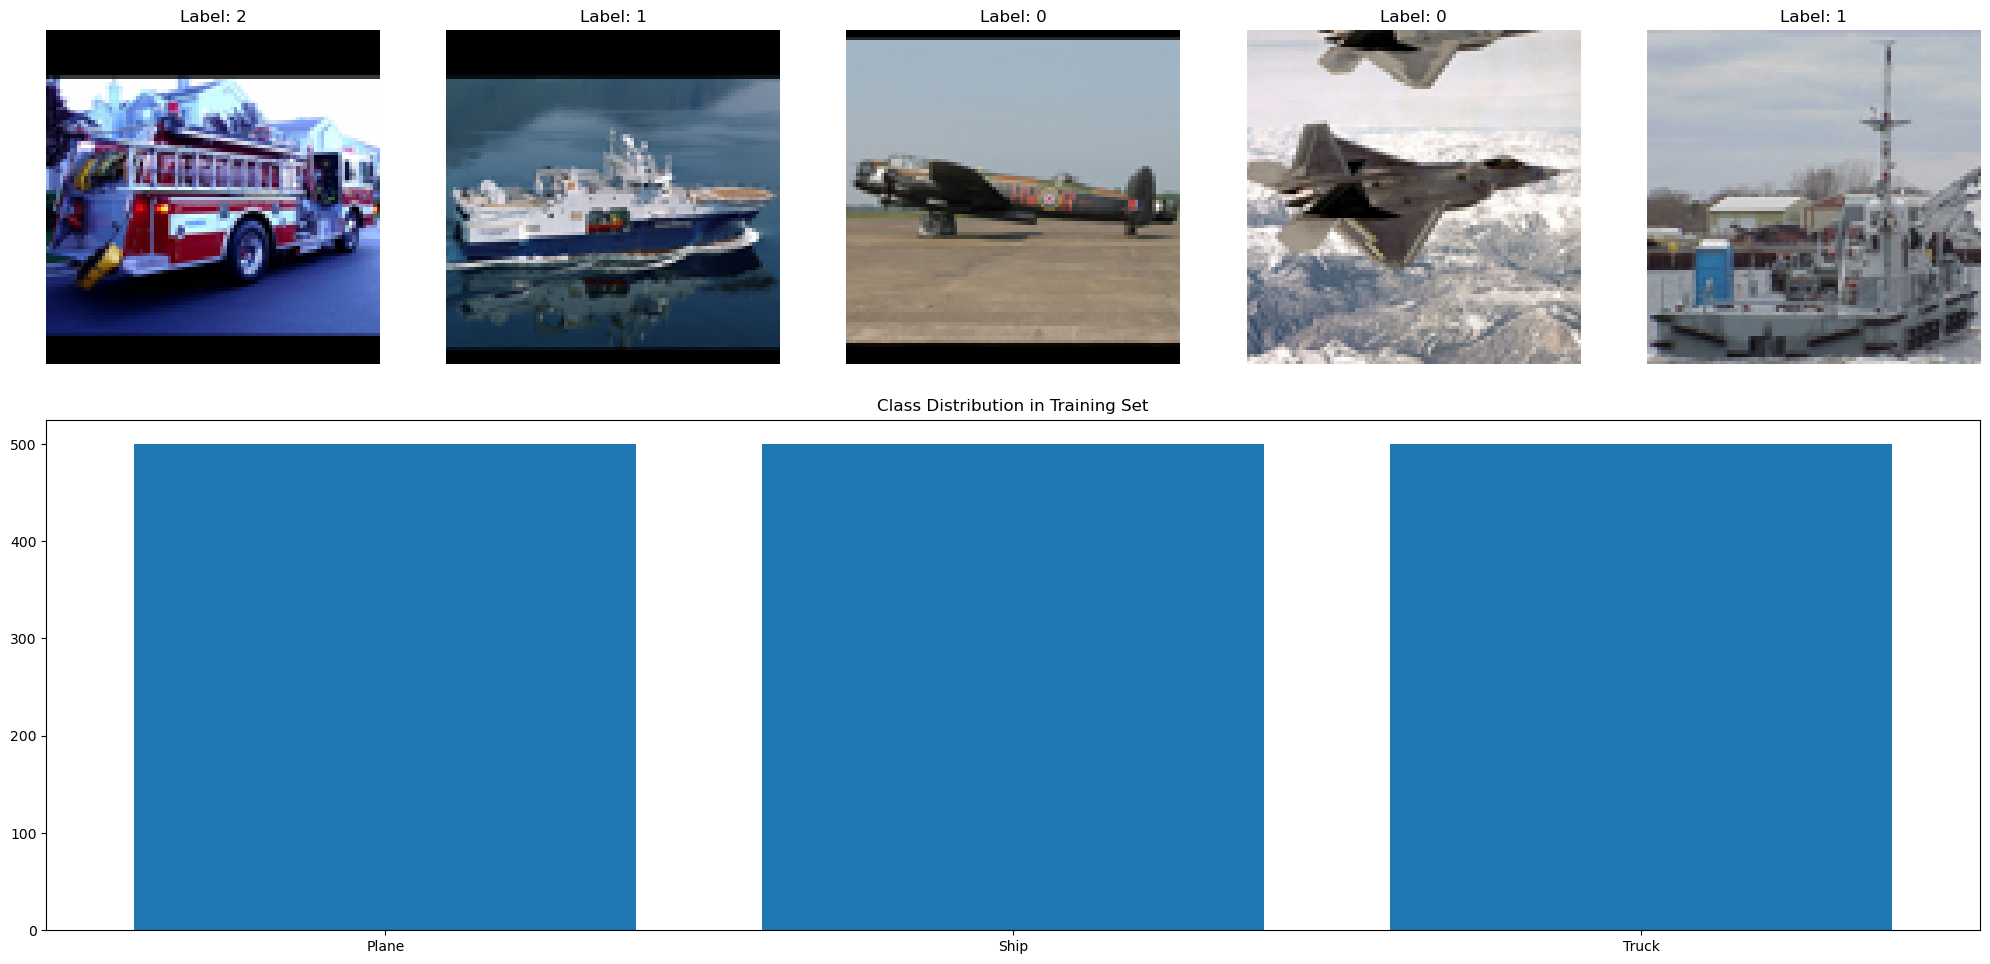

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Add the src folder to the Python path
sys.path.append(os.path.join(os.getcwd(), 'src/'))

training_data = np.load ('data/problem2/training_data.npz')
training_images = training_data ['a' ]
training_labels = training_data ['b']

print('training_images shape:', training_images.shape)
print('training_labels shape:', training_labels.shape)
# converting to dataframe
df = pd.DataFrame({
    'images': list(training_images), # Convert numpy array to list for DataFrame
    'labels': training_labels # Keep labels as is
})

# Display the first few rows of the DataFrame
print(df.head())

import matplotlib.gridspec as gridspec
from collections import Counter

counter = Counter(training_labels)

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1.2])

# Top row: display 5 sample images in a row
gs_top = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[0])
for i in range(5):
    ax = fig.add_subplot(gs_top[i])
    img = training_images[i].transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
    ax.imshow(img)
    ax.set_title(f"Label: {training_labels[i]}")
    ax.axis('off')

# Bottom row: bar chart for the class distribution
ax_bar = fig.add_subplot(gs[1])
ax_bar.bar(list(counter.keys()), list(counter.values()))
ax_bar.set_title("Class Distribution in Training Set")
ax_bar.set_xticks([0, 1, 2])
ax_bar.set_xticklabels(['Plane', 'Ship', 'Truck'])

plt.tight_layout()
plt.show()


In [2]:
from sklearn.model_selection import train_test_split



# Split indices
train_idx, val_idx = train_test_split(
    np.arange(len(training_labels)),
    test_size=0.2,
    stratify=training_labels,
    random_state=42
)

# Create sets
train_images = training_images[train_idx]
train_labels = training_labels[train_idx]
val_images = training_images[val_idx]
val_labels = training_labels[val_idx]


I kept the 2a config minimal to isolate the effect of BatchNorm. For 2c, I explored how Dropout benefits from additional regularization and LR scheduling.



=== Training: 2a_SGD_no_dropout_no_sched (Batch size: 32) ===


Training 2a_SGD_no_dropout_no_sched_bs32_20250418_123014:   3%|▎         | 144/4800 [00:17<05:53, 13.19batch/s, epoch=4/100, phase=train, loss=0.7786, acc=0.7812]

Patience remaining: 14


Training 2a_SGD_no_dropout_no_sched_bs32_20250418_123014:   4%|▍         | 193/4800 [00:21<05:37, 13.64batch/s, epoch=5/100, phase=train, loss=0.5545, acc=0.6875]

Patience remaining: 13


...

Patience remaining: 2


Training 2a_SGD_no_dropout_no_sched_bs32_20250418_123014:  37%|███▋      | 1777/4800 [03:19<04:01, 12.52batch/s, epoch=38/100, phase=train, loss=0.2880, acc=0.9375]

Patience remaining: 1


Training 2a_SGD_no_dropout_no_sched_bs32_20250418_123014:  38%|███▊      | 1824/4800 [03:25<05:34,  8.89batch/s, epoch=38/100, phase=val, loss=0.3912, acc=0.8333]  


Patience remaining: 0

Early stopping triggered at epoch 38.
Best validation accuracy was 0.9000 at epoch 23.

Best Val Accuracy: 0.9000
Total training time: 205.16s


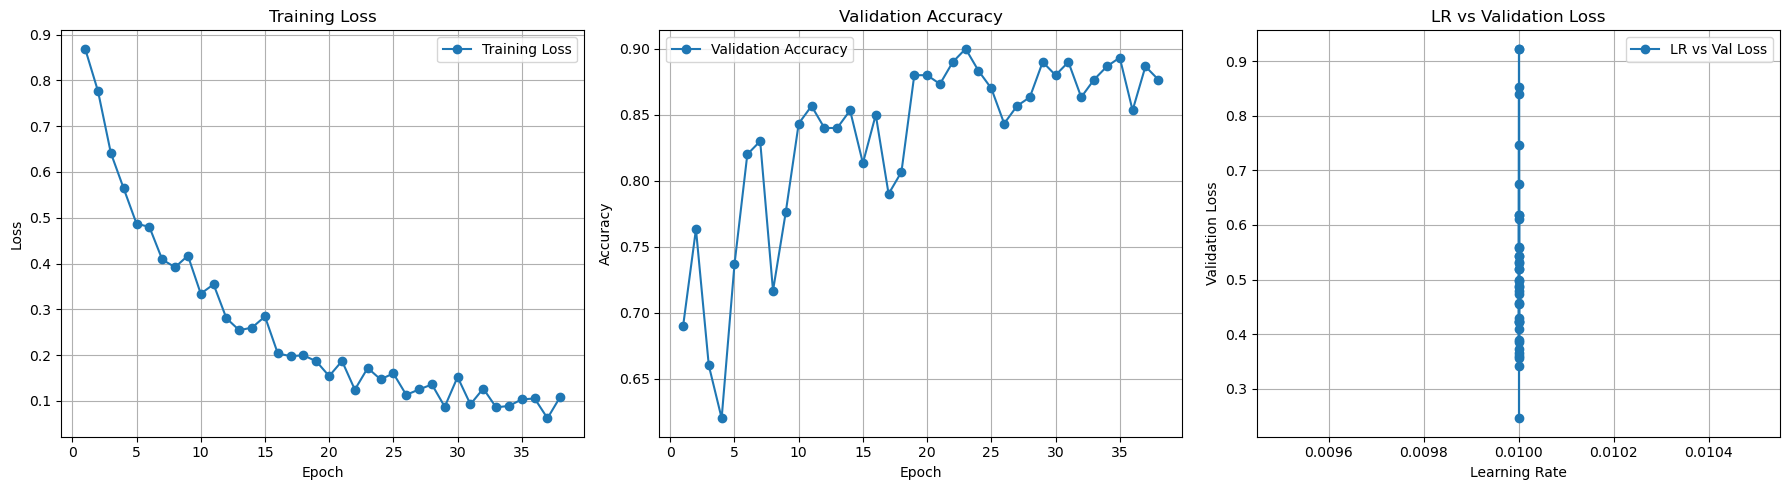

              precision    recall  f1-score   support

       Plane       0.92      0.82      0.87       100
        Ship       0.94      0.84      0.89       100
       Truck       0.80      0.97      0.87       100

    accuracy                           0.88       300
   macro avg       0.89      0.88      0.88       300
weighted avg       0.89      0.88      0.88       300

+------------------------------------------------------+
| Validation Loss: 0.4796, Validation Accuracy: 0.8767 |
+------------------------------------------------------+


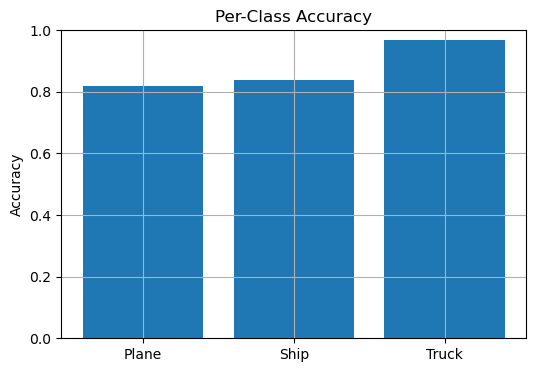



=== Training: 2a_Adam_no_dropout_no_sched (Batch size: 32) ===


Training 2a_Adam_no_dropout_no_sched_bs32_20250418_123342:   3%|▎         | 145/4800 [00:16<05:26, 14.25batch/s, epoch=4/100, phase=train, loss=0.5312, acc=0.8125]

Patience remaining: 14


Training 2a_Adam_no_dropout_no_sched_bs32_20250418_123342:   5%|▌         | 241/4800 [00:28<06:56, 10.94batch/s, epoch=6/100, phase=train, loss=0.5231, acc=0.8750]

Patience remaining: 14


...

Patience remaining: 2


Training 2a_Adam_no_dropout_no_sched_bs32_20250418_123342:  29%|██▉       | 1392/4800 [02:42<04:30, 12.61batch/s, epoch=30/100, phase=train, loss=0.0799, acc=0.9688]

Patience remaining: 1


Training 2a_Adam_no_dropout_no_sched_bs32_20250418_123342:  30%|███       | 1440/4800 [02:48<06:32,  8.57batch/s, epoch=30/100, phase=val, loss=1.4329, acc=0.6667]  


Patience remaining: 0

Early stopping triggered at epoch 30.
Best validation accuracy was 0.9067 at epoch 15.

Best Val Accuracy: 0.9067
Total training time: 168.10s


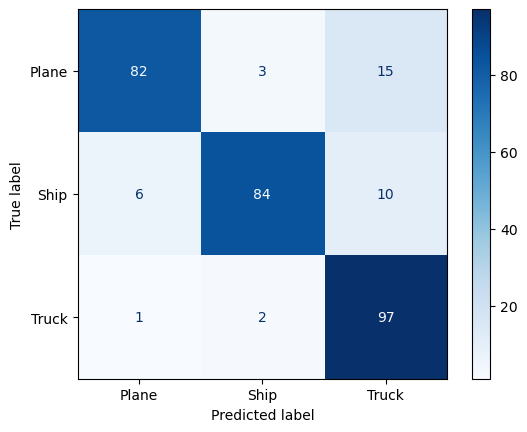

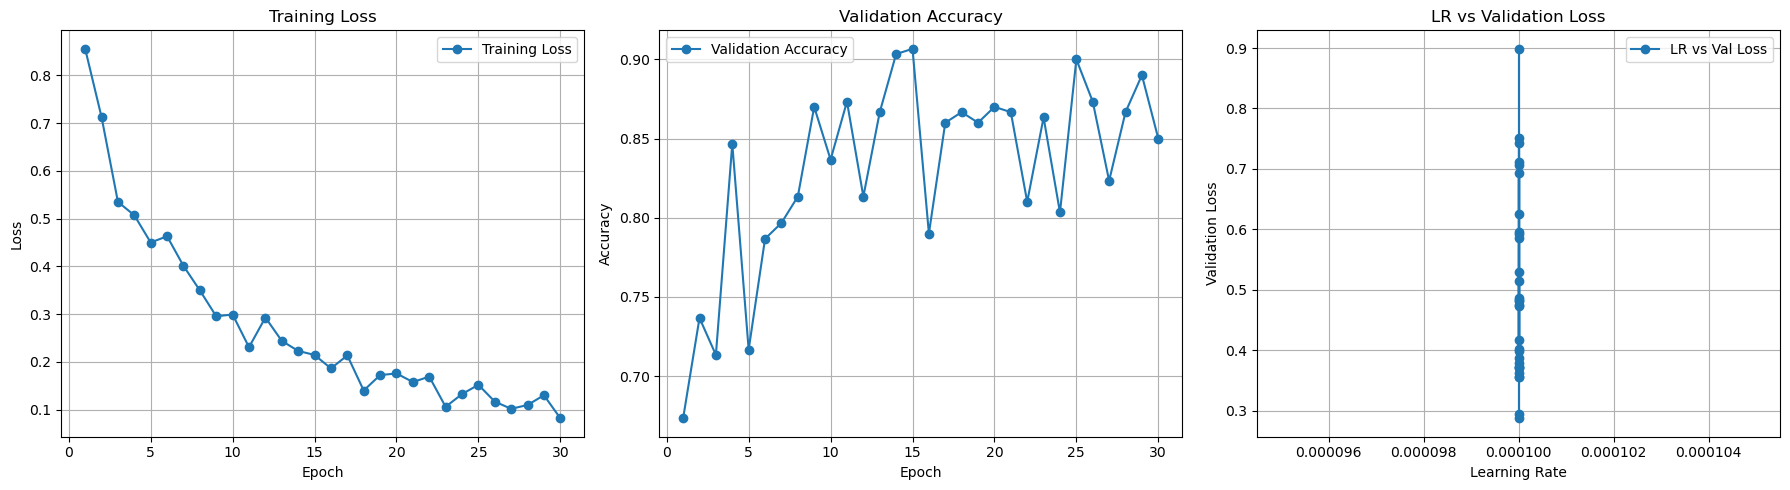

              precision    recall  f1-score   support

       Plane       0.97      0.78      0.87       100
        Ship       0.79      0.88      0.83       100
       Truck       0.82      0.89      0.86       100

    accuracy                           0.85       300
   macro avg       0.86      0.85      0.85       300
weighted avg       0.86      0.85      0.85       300

+------------------------------------------------------+
| Validation Loss: 0.5139, Validation Accuracy: 0.8500 |
+------------------------------------------------------+


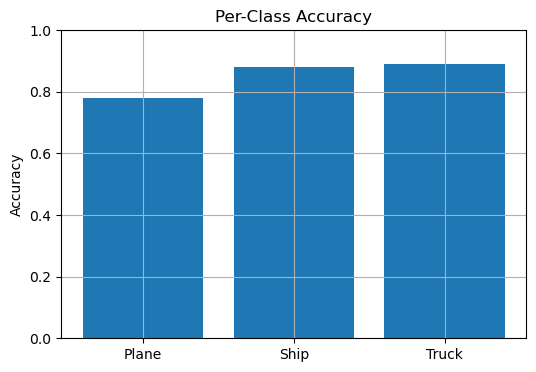



=== Training: 2c_SGD_dropout_sched (Batch size: 32) ===


Training 2c_SGD_dropout_sched_bs32_20250418_123633:   4%|▍         | 193/4800 [00:21<06:39, 11.53batch/s, epoch=5/100, phase=train, loss=0.5925, acc=0.7812]

Patience remaining: 14


Training 2c_SGD_dropout_sched_bs32_20250418_123633:   9%|▉         | 432/4800 [00:48<04:38, 15.67batch/s, epoch=10/100, phase=train, loss=0.4645, acc=0.8125]

Patience remaining: 14


...

Patience remaining: 2


Training 2c_SGD_dropout_sched_bs32_20250418_123633:  49%|████▉     | 2353/4800 [04:27<02:48, 14.51batch/s, epoch=50/100, phase=train, loss=0.0057, acc=1.0000]

Patience remaining: 1


Training 2c_SGD_dropout_sched_bs32_20250418_123633:  50%|█████     | 2400/4800 [04:32<04:32,  8.81batch/s, epoch=50/100, phase=val, loss=0.7336, acc=0.8333]  


Patience remaining: 0

Early stopping triggered at epoch 50.
Best validation accuracy was 0.9167 at epoch 35.

Best Val Accuracy: 0.9167
Total training time: 272.31s


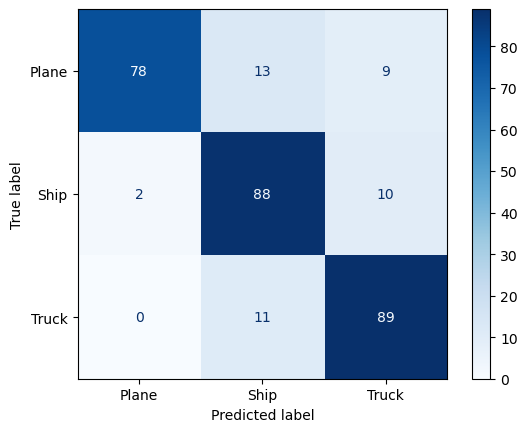

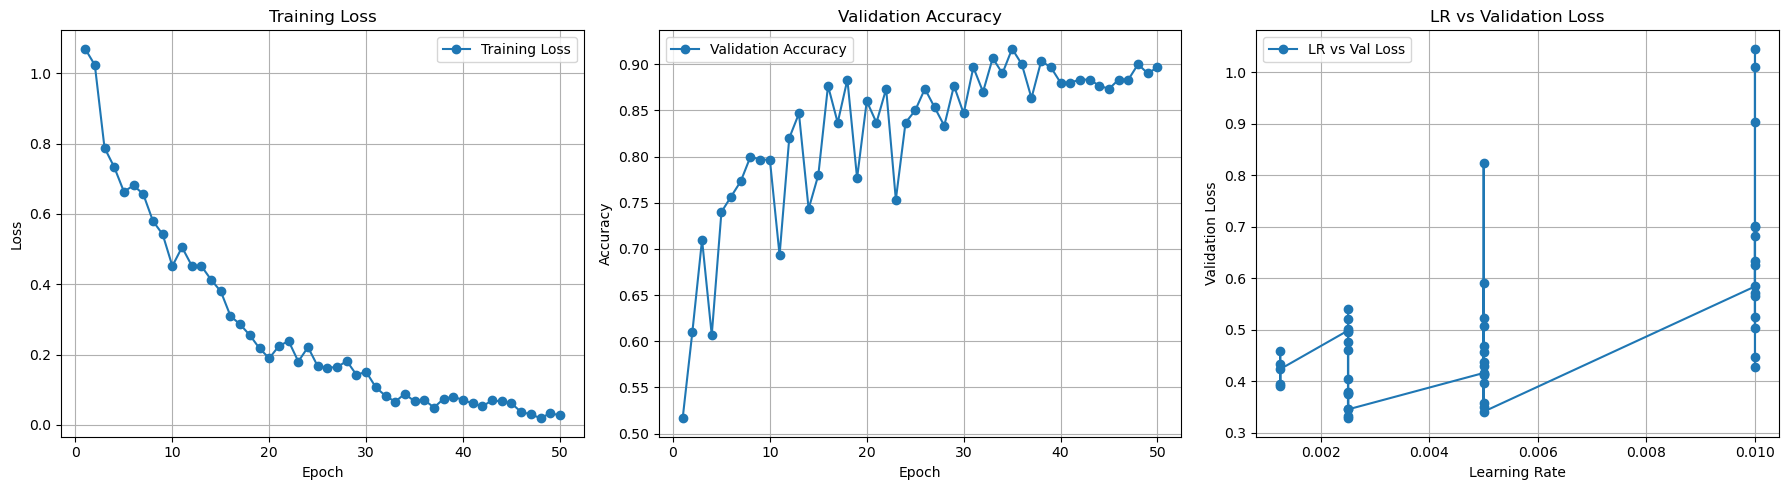

              precision    recall  f1-score   support

       Plane       0.94      0.85      0.89       100
        Ship       0.90      0.87      0.88       100
       Truck       0.86      0.97      0.91       100

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

+------------------------------------------------------+
| Validation Loss: 0.3953, Validation Accuracy: 0.8967 |
+------------------------------------------------------+


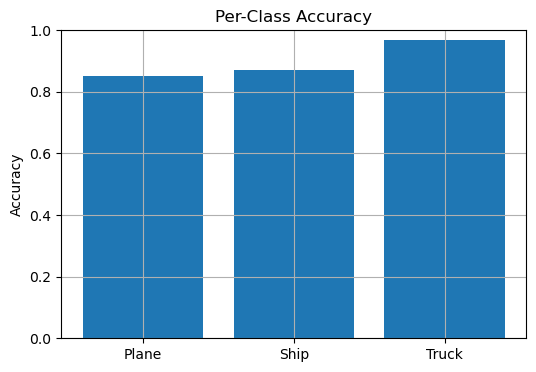



=== Training: 2c_Adam_dropout_sched (Batch size: 32) ===


Training 2c_Adam_dropout_sched_bs32_20250418_124109:   3%|▎         | 145/4800 [00:16<06:34, 11.80batch/s, epoch=4/100, phase=train, loss=0.6116, acc=0.7812]

Patience remaining: 14


Training 2c_Adam_dropout_sched_bs32_20250418_124109:   4%|▍         | 193/4800 [00:22<06:28, 11.87batch/s, epoch=5/100, phase=train, loss=0.5631, acc=0.7188]

Patience remaining: 13


...

Patience remaining: 2


Training 2c_Adam_dropout_sched_bs32_20250418_124109:  64%|██████▍   | 3071/4800 [06:01<02:13, 12.95batch/s, epoch=64/100, phase=val, loss=0.9641, acc=0.7500]  

Patience remaining: 1


Training 2c_Adam_dropout_sched_bs32_20250418_124109:  65%|██████▌   | 3120/4800 [06:06<03:17,  8.50batch/s, epoch=65/100, phase=val, loss=1.0481, acc=0.7500]  


Patience remaining: 0

Early stopping triggered at epoch 65.
Best validation accuracy was 0.9233 at epoch 50.

Best Val Accuracy: 0.9233
Total training time: 366.96s


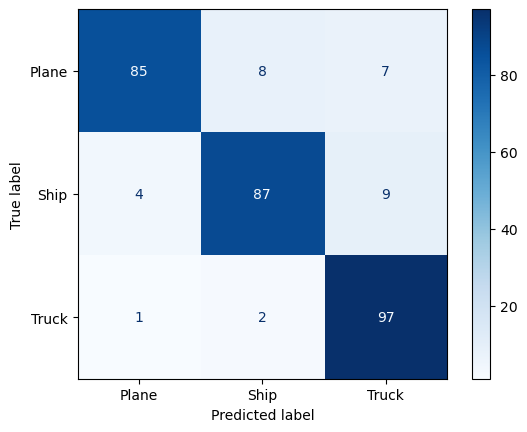

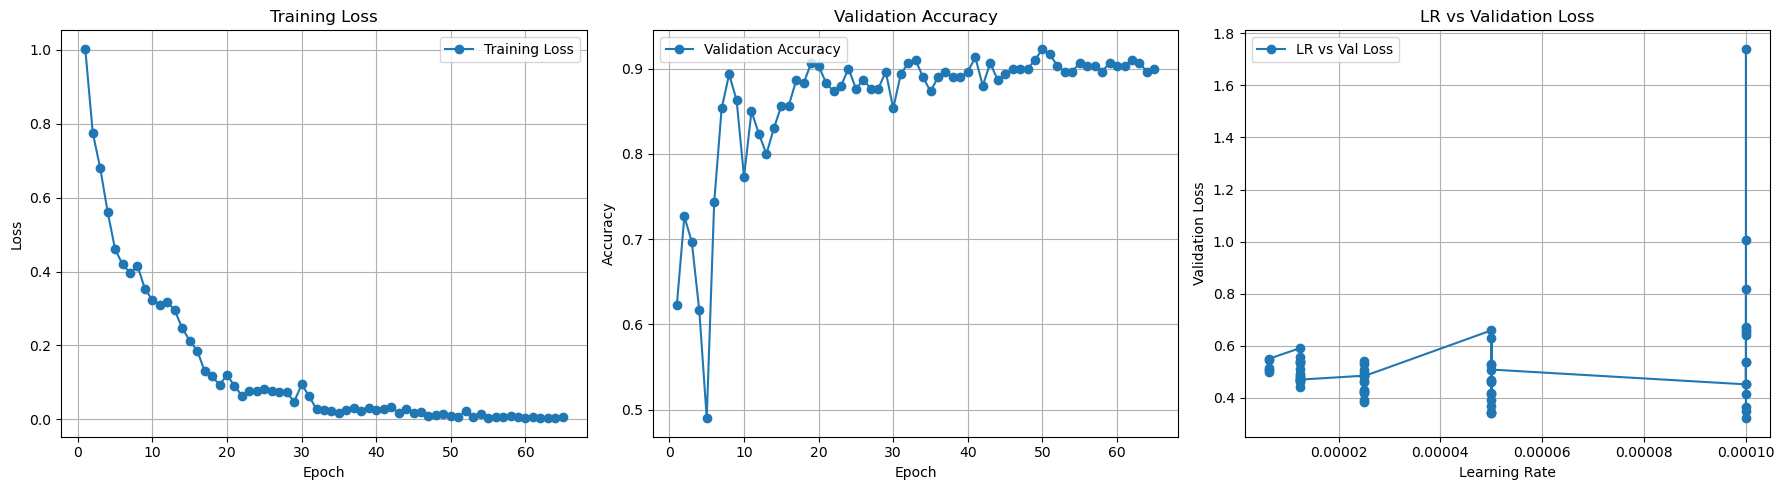

              precision    recall  f1-score   support

       Plane       0.88      0.91      0.89       100
        Ship       0.94      0.87      0.90       100
       Truck       0.89      0.92      0.91       100

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

+------------------------------------------------------+
| Validation Loss: 0.5136, Validation Accuracy: 0.9000 |
+------------------------------------------------------+


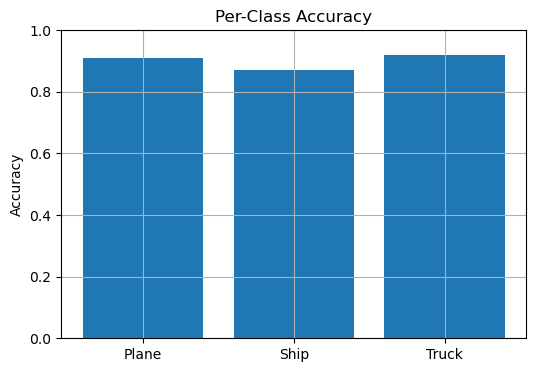

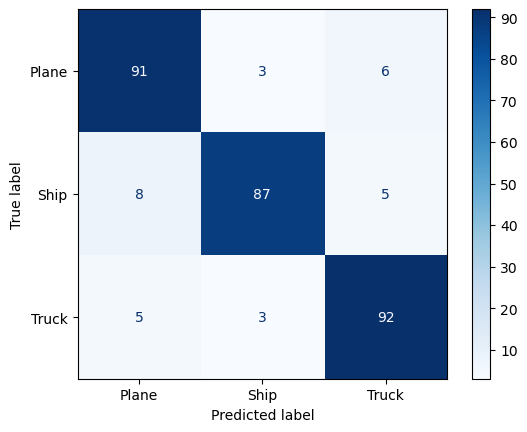

In [3]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset, set_seed, print_framed_metrics
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix, plot_per_class_accuracy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Defining data augmentation transforms for training
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Define validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


# Prepare datasets once
train_dataset = ImageDataset(train_images, train_labels, transform=train_transform)
val_dataset = ImageDataset(val_images, val_labels, transform=val_transform)

# can uncomment the following lines to create datasets again without augmentation
# train_dataset = ImageDataset(train_images, train_labels)
# val_dataset = ImageDataset(val_images, val_labels)

# Define experiment configurations
configs = [
    {
        "name": "2a_SGD_no_dropout_no_sched",
        "dropout": False,
        "optimizer": "sgd",
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 32
    },
    {
        "name": "2a_Adam_no_dropout_no_sched",
        "dropout": False,
        "optimizer": "adam",
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 32
    },
    {
        "name": "2c_SGD_dropout_sched",
        "dropout": True,
        "optimizer": "sgd",
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 32
    },
    {
        "name": "2c_Adam_dropout_sched",
        "dropout": True,
        "optimizer": "adam",
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 32
    }
]



# Run each experiment
for cfg in configs:
    print(f"\n\n=== Training: {cfg['name']} (Batch size: {cfg['batch_size']}) ===")

    # Create dataloaders with specified batch size
    dataloaders = {
        'train': DataLoader(
            train_dataset,
            batch_size=cfg['batch_size'],
            shuffle=True,
            pin_memory=True
        ),
        'val': DataLoader(
            val_dataset,
            batch_size=cfg['batch_size'],
            shuffle=False,
            pin_memory=True
        )
    }

    # Create model and loss function
    model = VGG11BN(num_classes=3, dropout=cfg["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Setup optimizer based on configuration
    optimizer_name = cfg.get("optimizer", "adam").lower()
    lr = cfg.get("lr", 1e-2 if optimizer_name == 'sgd' else 1e-4) # default lr for SGD and Adam; override in config if needed
    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"],momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"])

    # Setup scheduler (if any)
    scheduler = StepLR(optimizer, step_size=15, gamma=0.5) if cfg["use_scheduler"] else None

    # Train the model
    trained_model = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=100,
        model_name=f"{cfg['name']}_bs{cfg['batch_size']}",
        patience=15
    )

    # Evaluate the model
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=trained_model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print_framed_metrics(val_loss, val_acc)

    plot_per_class_accuracy(y_true, y_pred, class_names=['Plane', 'Ship', 'Truck'],
                        save_path=f"plots/{cfg['name']}_per_class_acc.png")

    # Generate plots
    plot_confusion_matrix(
        trained_model,
        dataloaders['val'],
        device,
        class_names=['Plane', 'Ship', 'Truck'],
        save_path=f"plots/{cfg['name']}_bs{cfg['batch_size']}_confusion_matrix.png"
    )
    





=== Training: 2c_SGD_dropout_sched (Batch size: 32) ===


Training 2c_SGD_dropout_sched_bs32_20250418_145552:   4%|▍         | 193/4800 [00:18<04:54, 15.63batch/s, epoch=5/100, phase=train, loss=0.6168, acc=0.7500]

Patience remaining: 14


Training 2c_SGD_dropout_sched_bs32_20250418_145552:   5%|▌         | 241/4800 [00:22<05:25, 14.01batch/s, epoch=6/100, phase=train, loss=0.7076, acc=0.7500]

Patience remaining: 13


...

Patience remaining: 2


Training 2c_SGD_dropout_sched_bs32_20250418_145552:  61%|██████    | 2929/4800 [04:42<02:04, 14.98batch/s, epoch=62/100, phase=train, loss=0.0824, acc=0.9688]

Patience remaining: 1


Training 2c_SGD_dropout_sched_bs32_20250418_145552:  62%|██████▏   | 2976/4800 [04:47<02:56, 10.35batch/s, epoch=62/100, phase=val, loss=0.4406, acc=0.7500]  


Patience remaining: 0

Early stopping triggered at epoch 62.
Best validation accuracy was 0.9100 at epoch 47.

Best Val Accuracy: 0.9100
Total training time: 287.49s


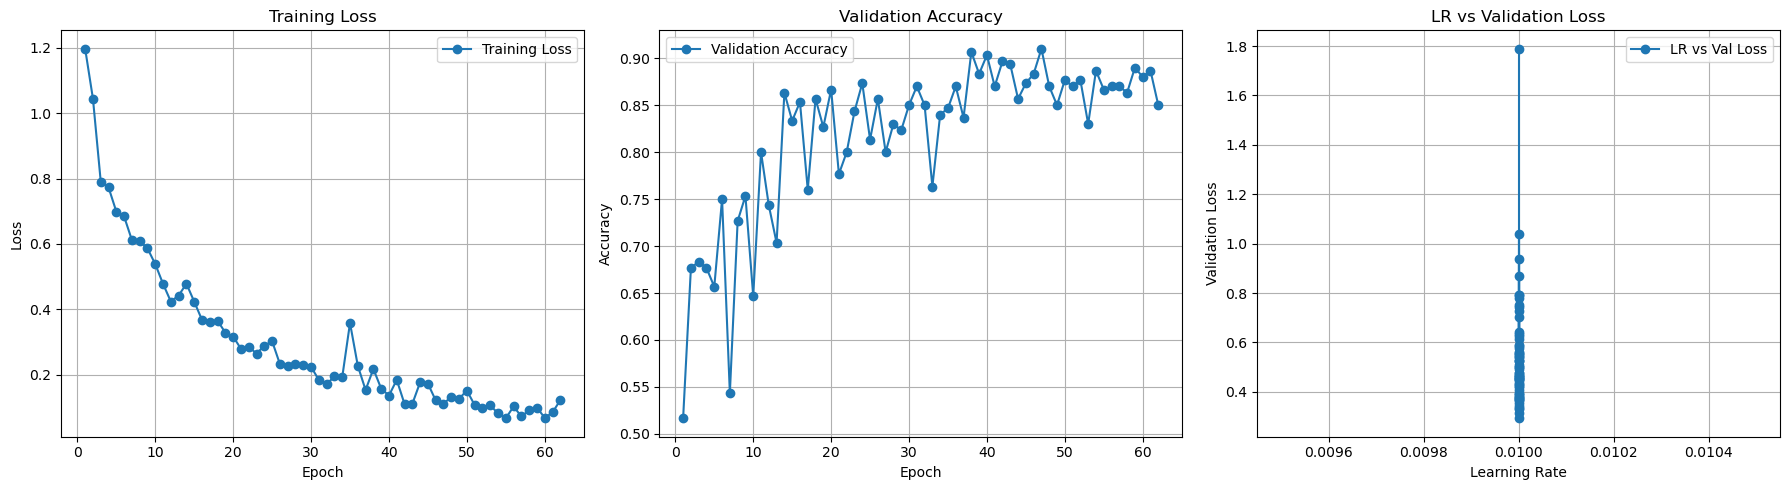

              precision    recall  f1-score   support

       Plane       0.79      0.89      0.84       100
        Ship       0.89      0.80      0.84       100
       Truck       0.89      0.86      0.87       100

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300

+------------------------------------------------------+
| Validation Loss: 0.3657, Validation Accuracy: 0.8500 |
+------------------------------------------------------+


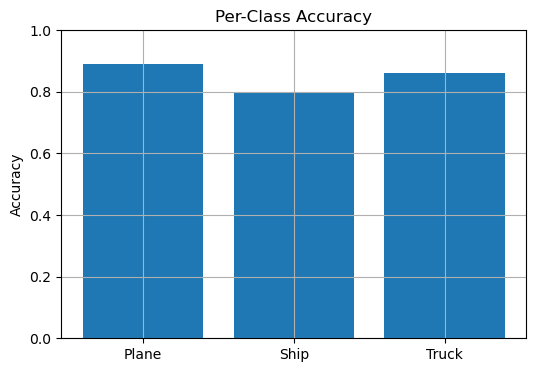



=== Training: 2c_Adam_dropout_sched (Batch size: 32) ===


Training 2c_Adam_dropout_sched_bs32_20250418_150043:   4%|▍         | 193/4800 [00:19<04:50, 15.86batch/s, epoch=5/100, phase=train, loss=0.8399, acc=0.7188]

Patience remaining: 14


Training 2c_Adam_dropout_sched_bs32_20250418_150043:   5%|▌         | 241/4800 [00:24<05:19, 14.28batch/s, epoch=6/100, phase=train, loss=0.4290, acc=0.8438]

Patience remaining: 13


...

Patience remaining: 2


Training 2c_Adam_dropout_sched_bs32_20250418_150043:  48%|████▊     | 2305/4800 [03:56<02:51, 14.58batch/s, epoch=49/100, phase=train, loss=0.0064, acc=1.0000]

Patience remaining: 1


Training 2c_Adam_dropout_sched_bs32_20250418_150043:  49%|████▉     | 2352/4800 [04:01<04:11,  9.73batch/s, epoch=49/100, phase=val, loss=0.6514, acc=0.9167]  


Patience remaining: 0

Early stopping triggered at epoch 49.
Best validation accuracy was 0.9100 at epoch 34.

Best Val Accuracy: 0.9100
Total training time: 241.63s


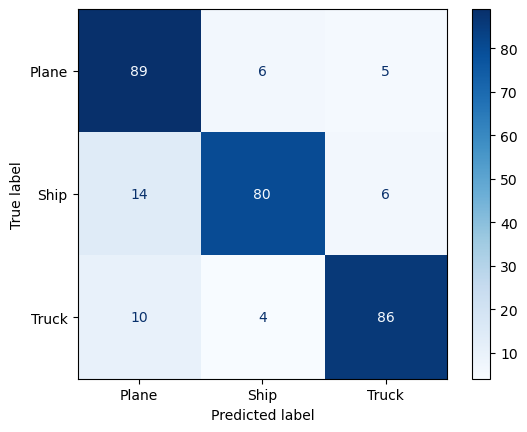

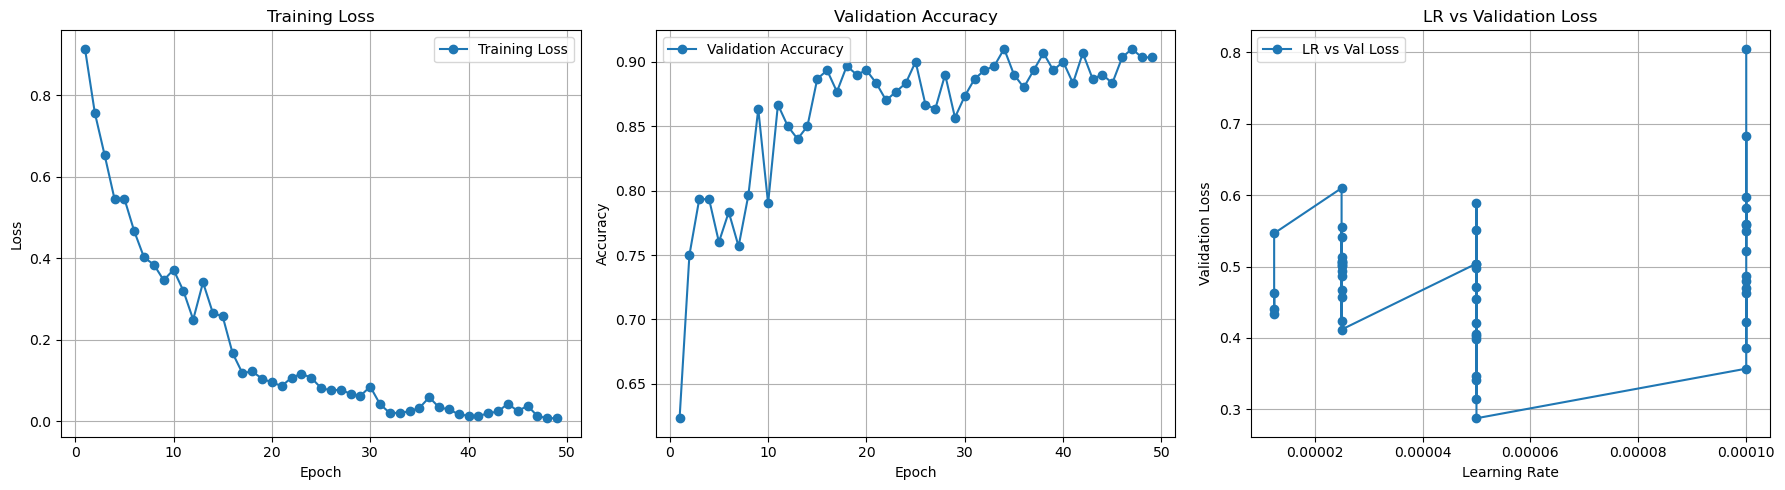

              precision    recall  f1-score   support

       Plane       0.94      0.87      0.90       100
        Ship       0.90      0.90      0.90       100
       Truck       0.88      0.94      0.91       100

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300

+------------------------------------------------------+
| Validation Loss: 0.4400, Validation Accuracy: 0.9033 |
+------------------------------------------------------+


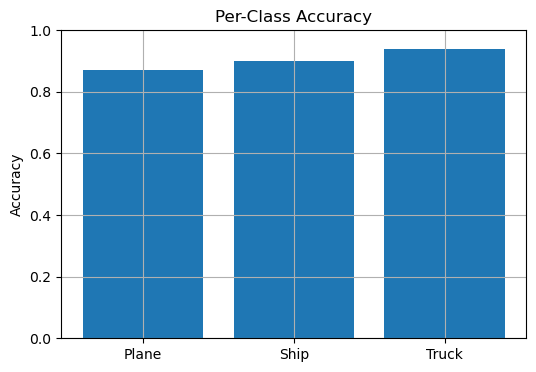

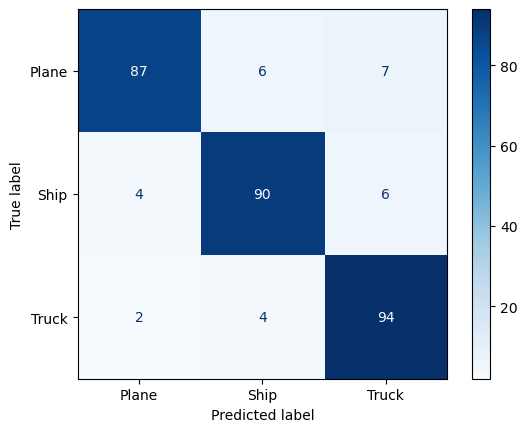

In [4]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset, set_seed, print_framed_metrics
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix, plot_per_class_accuracy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Defining data augmentation transforms for training
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Define validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


# Prepare datasets once
train_dataset = ImageDataset(train_images, train_labels, transform=train_transform)
val_dataset = ImageDataset(val_images, val_labels, transform=val_transform)

# can uncomment the following lines to create datasets again without augmentation
# train_dataset = ImageDataset(train_images, train_labels)
# val_dataset = ImageDataset(val_images, val_labels)

# Define experiment configurations
configs = [
    {
        "name": "2c_SGD_dropout_sched",
        "dropout": True,
        "optimizer": "sgd",
        "weight_decay": 1e-4,
        "use_scheduler": False,
        "batch_size": 32
    },
    {
        "name": "2c_Adam_dropout_sched",
        "dropout": True,
        "optimizer": "adam",
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 32
    }
]



# Run each experiment
for cfg in configs:
    print(f"\n\n=== Training: {cfg['name']} (Batch size: {cfg['batch_size']}) ===")

    # Create dataloaders with specified batch size
    dataloaders = {
        'train': DataLoader(
            train_dataset,
            batch_size=cfg['batch_size'],
            shuffle=True,
            pin_memory=True
        ),
        'val': DataLoader(
            val_dataset,
            batch_size=cfg['batch_size'],
            shuffle=False,
            pin_memory=True
        )
    }

    # Create model and loss function
    model = VGG11BN(num_classes=3, dropout=cfg["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Setup optimizer based on configuration
    optimizer_name = cfg.get("optimizer", "adam").lower()
    lr = cfg.get("lr", 1e-2 if optimizer_name == 'sgd' else 1e-4) # default lr for SGD and Adam; override in config if needed
    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"],momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"])

    # Setup scheduler (if any)
    scheduler = StepLR(optimizer, step_size=15, gamma=0.5) if cfg["use_scheduler"] else None

    # Train the model
    trained_model = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=100,
        model_name=f"{cfg['name']}_bs{cfg['batch_size']}",
        patience=15
    )

    # Evaluate the model
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=trained_model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print_framed_metrics(val_loss, val_acc)

    plot_per_class_accuracy(y_true, y_pred, class_names=['Plane', 'Ship', 'Truck'],
                        save_path=f"plots/{cfg['name']}_per_class_acc.png")

    # Generate plots
    plot_confusion_matrix(
        trained_model,
        dataloaders['val'],
        device,
        class_names=['Plane', 'Ship', 'Truck'],
        save_path=f"plots/{cfg['name']}_bs{cfg['batch_size']}_confusion_matrix.png"
    )
    





=== Training: 2c_Adam_dropout_sched (Batch size: 32) ===


Training 2c_Adam_dropout_sched_bs32_20250418_151701:   2%|▏         | 96/4800 [00:10<04:38, 16.91batch/s, epoch=3/100, phase=train, loss=1.2732, acc=0.3125]

Patience remaining: 14


Training 2c_Adam_dropout_sched_bs32_20250418_151701:   6%|▌         | 289/4800 [00:30<04:37, 16.24batch/s, epoch=7/100, phase=train, loss=0.7374, acc=0.7500]

Patience remaining: 14


...

Patience remaining: 2


Training 2c_Adam_dropout_sched_bs32_20250418_151701:  61%|██████    | 2929/4800 [05:02<02:00, 15.56batch/s, epoch=62/100, phase=train, loss=0.1438, acc=0.9688]

Patience remaining: 1


Training 2c_Adam_dropout_sched_bs32_20250418_151701:  62%|██████▏   | 2976/4800 [05:07<03:08,  9.69batch/s, epoch=62/100, phase=val, loss=0.1598, acc=0.9167]  


Patience remaining: 0

Early stopping triggered at epoch 62.
Best validation accuracy was 0.9067 at epoch 47.

Best Val Accuracy: 0.9067
Total training time: 307.15s


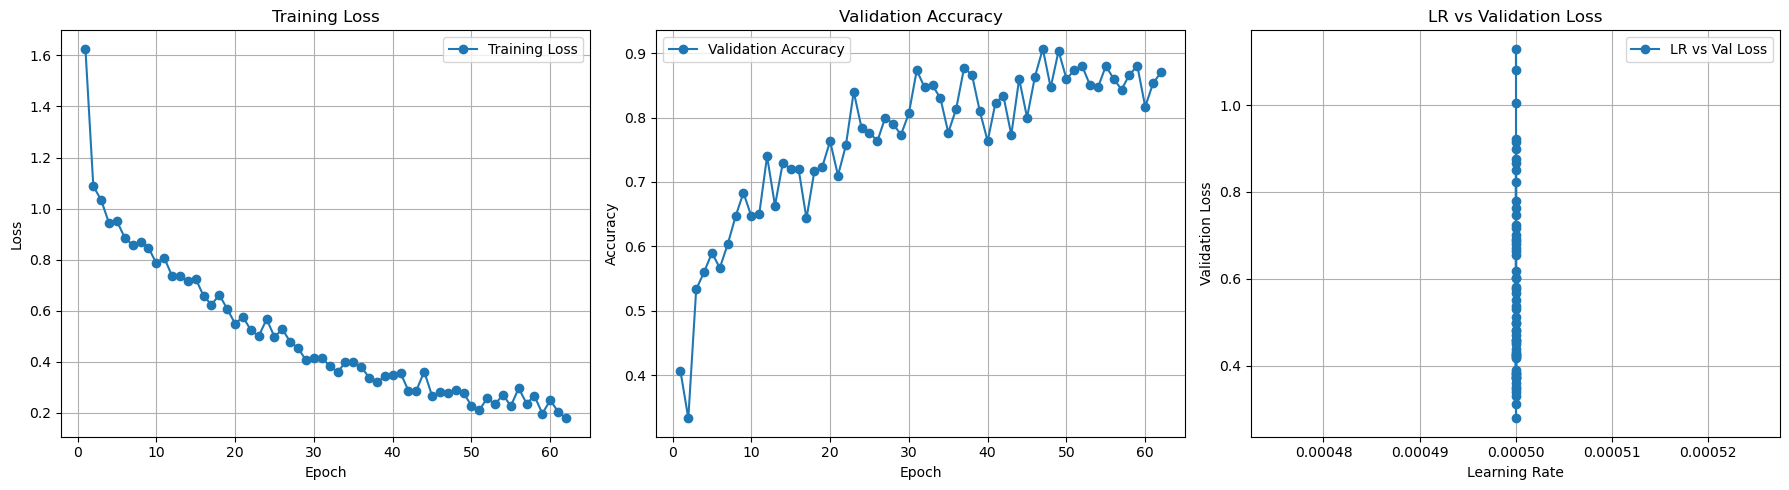

              precision    recall  f1-score   support

       Plane       0.84      0.95      0.89       100
        Ship       0.92      0.76      0.83       100
       Truck       0.87      0.90      0.88       100

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300

+------------------------------------------------------+
| Validation Loss: 0.3713, Validation Accuracy: 0.8700 |
+------------------------------------------------------+


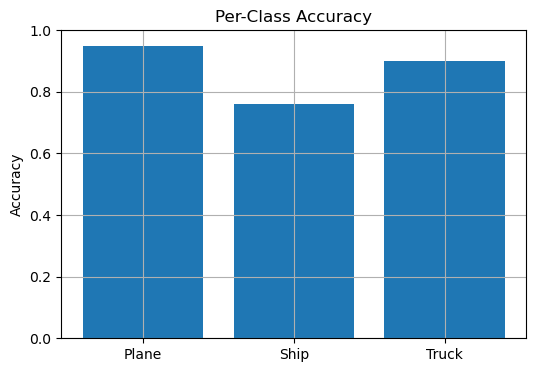

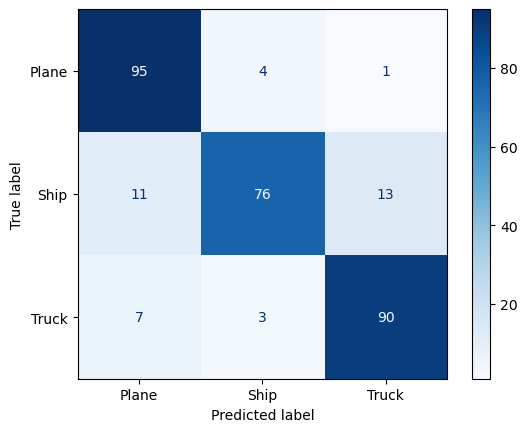

In [6]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset, set_seed, print_framed_metrics
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix, plot_per_class_accuracy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Defining data augmentation transforms for training
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Define validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


# Prepare datasets once
train_dataset = ImageDataset(train_images, train_labels, transform=train_transform)
val_dataset = ImageDataset(val_images, val_labels, transform=val_transform)

# can uncomment the following lines to create datasets again without augmentation
# train_dataset = ImageDataset(train_images, train_labels)
# val_dataset = ImageDataset(val_images, val_labels)

# Define experiment configurations
configs = [
    {
        "name": "2c_Adam_dropout_sched",
        "dropout": True,
        "optimizer": "adam",
        "weight_decay": 1e-4,
        "use_scheduler": False,
        "batch_size": 32
    }
]



# Run each experiment
for cfg in configs:
    print(f"\n\n=== Training: {cfg['name']} (Batch size: {cfg['batch_size']}) ===")

    # Create dataloaders with specified batch size
    dataloaders = {
        'train': DataLoader(
            train_dataset,
            batch_size=cfg['batch_size'],
            shuffle=True,
            pin_memory=True
        ),
        'val': DataLoader(
            val_dataset,
            batch_size=cfg['batch_size'],
            shuffle=False,
            pin_memory=True
        )
    }

    # Create model and loss function
    model = VGG11BN(num_classes=3, dropout=cfg["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Setup optimizer based on configuration
    optimizer_name = cfg.get("optimizer", "adam").lower()
    lr = cfg.get("lr", 1e-2 if optimizer_name == 'sgd' else 5e-4) # default lr for SGD and Adam; override in config if needed
    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"],momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"])

    # Setup scheduler (if any)
    scheduler = StepLR(optimizer, step_size=15, gamma=0.5) if cfg["use_scheduler"] else None

    # Train the model
    trained_model = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=100,
        model_name=f"{cfg['name']}_bs{cfg['batch_size']}",
        patience=15
    )

    # Evaluate the model
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=trained_model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print_framed_metrics(val_loss, val_acc)

    plot_per_class_accuracy(y_true, y_pred, class_names=['Plane', 'Ship', 'Truck'],
                        save_path=f"plots/{cfg['name']}_per_class_acc.png")

    # Generate plots
    plot_confusion_matrix(
        trained_model,
        dataloaders['val'],
        device,
        class_names=['Plane', 'Ship', 'Truck'],
        save_path=f"plots/{cfg['name']}_bs{cfg['batch_size']}_confusion_matrix.png"
    )
    



In [7]:
# === Load and evaluate best saved model ===

import torch
from src.vgg11bn import VGG11BN
from src.evaluation import classification_summary, plot_confusion_matrix, plot_multiclass_roc
from torch import nn

# === Replace this with the actual path to your best model ===
best_model_path = "models/2c_Adam_dropout_lr5e4_20250418_15043_best.pth"

# === Rebuild the same model architecture as used during training ===
model = VGG11BN(num_classes=3, dropout=True)  # <-- Set dropout=True/False as used in training
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

# === Loss function (same as training) ===
criterion = nn.CrossEntropyLoss()

# === Evaluate and print classification summary ===
val_loss, val_acc, y_true, y_pred = classification_summary(
    model=model,
    dataloader=dataloaders["val"],
    criterion=criterion,
    device=device,
    class_names=['Plane', 'Ship', 'Truck']
)

print(f"\n🧪 Best Model Evaluation:\nValidation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

# === Optional plots ===
plot_confusion_matrix(model, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'])
plot_multiclass_roc(model, dataloaders['val'], device, num_classes=3, class_names=['Plane', 'Ship', 'Truck'])


/tmp/ipykernel_470/1680480498.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


FileNotFoundError: [Errno 2] No such file or directory: 'models/2c_Adam_dropout_lr5e4_20250418_15043_best.pth'